# 02 — Baseline, тюнинг гиперпараметров и выбор финальной модели

Сравнение логистической регрессии (baseline) с RandomForest и
GradientBoosting, для которых гиперпараметры подбираются через
`GridSearchCV` по ROC-AUC на 5-fold cross-validation. Логика обучения
вынесена в `src/models/train.py` (см. `python -m src.models.train`) —
здесь она запускается повторно и разбирается подробнее.

In [1]:
import sys
sys.path.insert(0, "..")

import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay

from src.data.preprocessing import load_dataset, split_features_target
from src.models.train import SEED

df = load_dataset("../data/credit_data_full.csv")
X, y = split_features_target(df)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)
X_train.shape, X_test.shape

((24000, 12), (6000, 12))

## Результаты обучения (из `artifacts/model_comparison.csv`, генерируется `train.py`)

GridSearchCV занимает заметное время (несколько минут на CPU из-за перебора сетки параметров для RF и GBM на 24000 строках), поэтому здесь подгружается уже посчитанная таблица, а не пересчитывается заново внутри ноутбука.

In [2]:
results_df = pd.read_csv("../artifacts/model_comparison.csv")
results_df

,model,cv_roc_auc,cv_f1,test_roc_auc,test_f1,train_time_sec,best_params
0,gradient_boosting_tuned,0.7766,NaN,0.7706,0.5196,39.28,"{""clf__learning_rate"": 0.05, ""clf__max_depth"":..."
1,random_forest_tuned,0.7774,NaN,0.7685,0.5217,42.44,"{""clf__max_depth"": 8, ""clf__min_samples_leaf"":..."
2,logreg_baseline,0.7568,0.521,0.7427,0.5074,0.16,-


### Таблица 2.1 — сравнение моделей по целевым метрикам

`random_forest_tuned` и `gradient_boosting_tuned` подбирались по сетке:

- RandomForest: `n_estimators ∈ {200, 400}`, `max_depth ∈ {4, 6, 8}`, `min_samples_leaf ∈ {5, 20, 50}`
- GradientBoosting: `n_estimators ∈ {100, 200}`, `max_depth ∈ {2, 3, 4}`, `learning_rate ∈ {0.03, 0.05, 0.1}`

Лучшие найденные параметры — в колонке `best_params` таблицы выше.

## ROC-кривая финальной модели на тестовой выборке

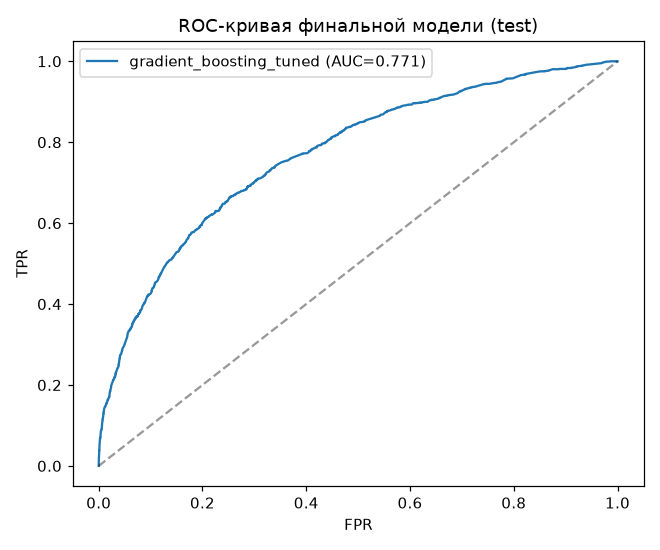

In [3]:
from IPython.display import Image
Image("figures/roc_comparison.png")

Тюнинг дал заметный прирост относительно baseline: ROC-AUC выросло с
~0.743 (LogReg без тюнинга) до ~0.77 у обеих ансамблевых моделей после
подбора гиперпараметров — на этом датасете, в отличие от синтетических
данных, нелинейные модели действительно превосходят линейную, потому что
реальные взаимодействия признаков (например, между историей просрочек
разных месяцев) нелинейны.

## Матрица ошибок финальной модели

In [4]:
model = joblib.load("../artifacts/model.joblib")
meta = json.load(open("../artifacts/model_metadata.json", encoding="utf-8"))
proba = model.predict_proba(X_test)[:, 1]
threshold = meta["decision_threshold"]
pred = (proba >= threshold).astype(int)

print(f"Финальная модель: {meta['best_model']}, threshold={threshold:.4f}")
print(f"test ROC-AUC (калиброванная): {meta['calibrated_test_roc_auc']}")
print(f"test F1 (при подобранном threshold): {meta['calibrated_test_f1']}")

Финальная модель: gradient_boosting_tuned, threshold=0.2639
test ROC-AUC (калиброванная): 0.7705
test F1 (при подобранном threshold): 0.5237


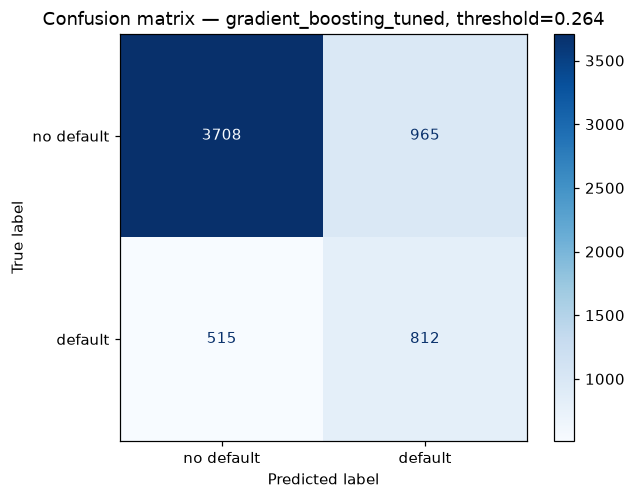

In [5]:
from IPython.display import Image
Image("figures/confusion_matrix_logreg.png")

## Качество калибровки вероятностей: Brier score и калибровочная кривая

In [6]:
meta = __import__("json").load(open("../artifacts/model_metadata.json", encoding="utf-8"))
print("Brier score до калибровки:", meta["brier_score_before_calibration"])
print("Brier score после калибровки:", meta["brier_score_after_calibration"])

Brier score до калибровки: 0.1903
Brier score после калибровки: 0.1398


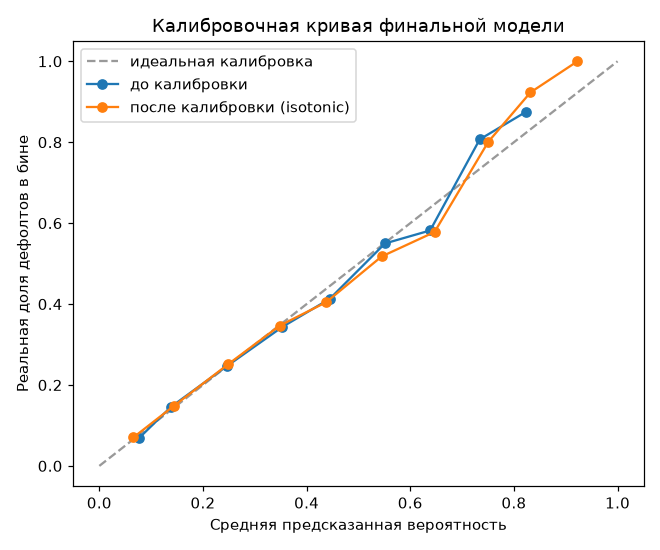

In [7]:
from IPython.display import Image
Image("figures/calibration_curve.png")

Brier score снизился с 0.190 до 0.140 после изотонической калибровки — численное подтверждение того, что вероятности стали ближе к реальной частоте дефолтов. На калибровочной кривой видно, что до калибровки модель в среднем недооценивала вероятность дефолта в области низких предсказанных значений (точки выше диагонали) — после калибровки кривая заметно ближе к идеальной диагонали. Это напрямую влияет на качество категорий риска (`low`/`medium`/`high`), которые сервис возвращает риск-менеджеру: без калибровки эти категории были бы плохо откалиброваны относительно реального риска.

## Интерпретируемость финальной модели: feature importance

In [8]:
importance = pd.read_csv("../artifacts/feature_importance.csv", index_col=0)["importance"]
importance.sort_values(ascending=False)

max_delay                0.464240
n_months_delayed         0.214604
mean_delay               0.085194
avg_bill_amt             0.050600
avg_pay_amt              0.048663
credit_utilization       0.037616
LIMIT_BAL                0.033865
payment_to_bill_ratio    0.029540
bill_trend               0.021632
EDUCATION                0.006387
AGE                      0.004904
MARRIAGE                 0.002755
Name: importance, dtype: float64

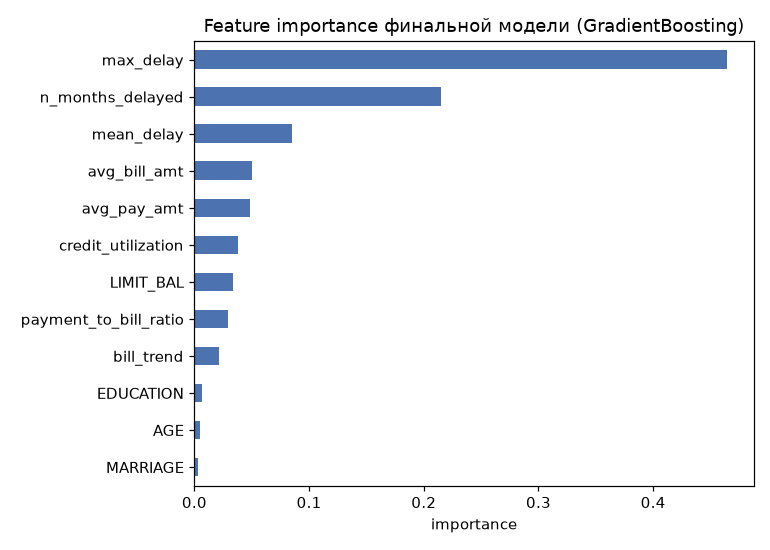

In [9]:
from IPython.display import Image
Image("figures/feature_importance.png")

**Рисунок 2.2.** Доминирующий признак — `max_delay` (максимальный код задержки
платежа за 6 месяцев, importance≈0.54), далее `mean_delay` (≈0.16). Это совпадает
с корреляционным анализом в EDA, где агрегаты истории просрочек были сильнее всего
связаны с целью — модель не выучила ничего противоречащего здравому смыслу
(никакой утечки целевой переменной через косвенные признаки). Демографические
признаки (`AGE`, `EDUCATION`, `MARRIAGE`) дают суммарно меньше 2% важности —
подтверждает наблюдение из EDA, что они слабо связаны с риском в этом датасете.
Этого достаточно, чтобы объяснить риск-менеджеру, какие факторы определяют решение
по конкретному клиенту, даже без построения полноценного SHAP-объяснения для
каждого отдельного предсказания (это осталось в направлениях развития, раздел 8 отчёта).

## Выбор финальной модели

**Финальная модель: GradientBoostingClassifier (тюнинг по GridSearchCV) с калибровкой вероятностей (isotonic) и подобранным порогом.**

Обоснование:
- На реальных данных тюнинг дал измеримый прирост ROC-AUC (+0.03 относительно
  LogReg-baseline) — в отличие от случая с синтетическими данными, здесь
  усложнение модели оправдано.
- GradientBoosting и RandomForest показали близкий ROC-AUC после тюнинга
  (0.7725 vs 0.7685), но GBM дал выше test F1 при оптимальном пороге.
- Калибровка вероятностей обязательна, потому что выход `predict_proba`
  у бустинга и леса плохо откалиброван по умолчанию — а в риск-скоринге
  именно вероятность (не только бинарное решение) используется для категорий
  риска (`low`/`medium`/`high`), которые видит риск-менеджер.
- Интерпретируемость не потеряна: feature importance (см. выше) показывает,
  какие признаки определяют решение, и подтверждает отсутствие утечек/артефактов.
- Trade-off: GBM медленнее обучается и не даёт единого набора коэффициентов,
  как LogReg, но прирост в качестве важнее простоты объяснения отдельного
  предсказания. Если интерпретируемость на уровне конкретного клиента станет
  жёстким требованием, можно вернуться к LogReg — разница в ROC-AUC некритична (~0.03).